# Ajuste de Curvas por Algoritmos Evolutivos

Este notebook apresenta a aplicação de dois algoritmos bio-inspirados — **Particle Swarm Optimization (PSO)** e **Algoritmo Genético (GA)** — para o problema de ajuste de curvas (*curve fitting*).

O objetivo é encontrar os coeficientes $a$, $b$ e $c$ de um polinômio quadrático da forma:

$$\hat{y} = a + b \cdot x + c \cdot x^2$$

que minimize o erro quadrático total entre os valores preditos e os dados reais:

$$\text{fitness} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Cada algoritmo é executado **10 vezes** de forma independente. Ao final, são exibidos os gráficos de curva ajustada, a evolução do melhor fitness por execução e uma tabela comparativa com a média e o melhor resultado das execuções.

## Importações

In [12]:
from abc import ABC, abstractmethod
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sko.PSO import PSO
from sko.GA import GA

## Classe `Dataset`

Responsável por carregar e armazenar os dados de entrada ($x$ e $y$) a partir de arquivos de texto. Realiza validação básica dos dados e expõe os vetores como arrays NumPy.

In [ ]:
class Dataset:
    def __init__(self, x_data: List[float], y_data: List[float]):
        self.__validate_data(x_data, y_data)
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)

    def __validate_data(self, x_data: List[float], y_data: List[float]):
        if len(x_data) != len(y_data):
            raise ValueError("x_data and y_data must have the same length.")

        if not all(isinstance(x, (int, float)) for x in x_data):
            raise ValueError("All elements in x_data must be numbers.")

        if not all(isinstance(y, (int, float)) for y in y_data):
            raise ValueError("All elements in y_data must be numbers.")

    @classmethod
    def from_txts(cls, x_data_path: str, y_data_path: str):
        x_data = cls.__read_txt(x_data_path)
        y_data = cls.__read_txt(y_data_path)

        return cls(x_data, y_data)

    @classmethod
    def __read_txt(cls, file_path: str) -> List[float]:
        with open(file_path, 'r') as file:
            return [float(line.strip()) for line in file.readlines()]

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx: int):
        return self.x_data[idx], self.y_data[idx]

    def x_i(self, idx: int):
        return self.x_data[idx]

    def y_i(self, idx: int):
        return self.y_data[idx]

    @property
    def x(self) -> np.ndarray:
        return self.x_data

    @property
    def y(self) -> np.ndarray:
        return self.y_data

## Classe Base `Algorithm`

Classe abstrata que define a interface e o comportamento comum aos dois algoritmos. Inclui o cálculo da função de aptidão (*fitness*), a execução múltipla via `run_many_times`, e os métodos de plotagem da curva ajustada e da evolução do melhor fitness ao longo das iterações.

In [14]:
class Algorithm(ABC):
    def __init__(self, dataset: Dataset):
        self.dataset = dataset

        self.individuals: List[np.ndarray] = []
        self.fitness_values: List[float] = []
        self.best_fitness_values_history: List[List[float]] = []

        self.best_individual: Optional[np.ndarray] = None
        self.best_fitness: float = float('inf')

    def run_many_times(self, times: int):
        self.individuals = []
        self.fitness_values = []
        self.best_fitness_values_history = []

        for _ in range(times):
            gbest_x, gbest_y = self.run()
            self.individuals.append(gbest_x)
            self.fitness_values.append(gbest_y)

        best_idx = np.argmin(self.fitness_values)
        self.best_individual = self.individuals[best_idx]
        self.best_fitness = self.fitness_values[best_idx]

    @abstractmethod
    def run(self) -> Tuple[np.ndarray, float]:
        pass

    @abstractmethod
    def name(self) -> str:
        pass

    def fitness(self, individual: np.ndarray) -> float:
        a: float = individual[0]
        b: float = individual[1]
        c: float = individual[2]

        x = self.dataset.x
        y = self.dataset.y

        y_pred = a + b * x + c * x * x

        return ((y - y_pred) ** 2).sum()

    def plot_curve_graphic(self) -> None:
        a: float = self.best_individual[0]
        b: float = self.best_individual[1]
        c: float = self.best_individual[2]

        x_plot = np.linspace(self.dataset.x.min(), self.dataset.x.max(), 300)
        y_plot = a + b * x_plot + c * x_plot * x_plot

        plt.figure(figsize=(10, 6))
        plt.scatter(self.dataset.x, self.dataset.y, color='blue', label='Data Points')
        plt.plot(x_plot, y_plot, color='red', label='Fitted Curve')
        plt.title(f'Curve Fitting using {self.name()}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_best_fitness_graphic(self) -> None:
        plt.figure(figsize=(10, 6))

        for idx, history in enumerate(self.best_fitness_values_history):
            cummin_history = np.minimum.accumulate(history)
            plt.plot(cummin_history, label=f'Run {idx + 1}', alpha=0.7, linewidth=1.5)

        plt.xlabel('Iteration')
        plt.ylabel('Best Fitness')
        plt.title(f'Best Fitness Evolution - {self.name()}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def get_dataframe_row(self) -> Dict[str, float]:
        return {
            'algorithm': self.name(),
            'mean_fitness': np.mean(self.fitness_values),
            'min_fitness': np.min(self.fitness_values)
        }

## PSO — Particle Swarm Optimization

O PSO simula o comportamento de um bando de pássaros em busca de alimento. Cada partícula representa uma solução candidata e se move no espaço de busca influenciada pela sua melhor posição histórica e pela melhor posição já encontrada pelo enxame.

**Parâmetros utilizados:**
- Tamanho da população: 100 partículas
- Máximo de iterações: 1000
- Limites do espaço de busca: $[-5, 5]$ para cada dimensão
- Inércia ($w$): 0,729 | Componente cognitivo ($c_1$): 2 | Componente social ($c_2$): 2

In [15]:
class PsoAlgorithm(Algorithm):
    POPULATION_SIZE = 100
    MAX_ITERATIONS = 1000
    LOWER_BOUND = -5
    UPPER_BOUND = 5
    W = 0.729
    C1 = 2
    C2 = 2

    def name(self) -> str:
        return 'Particle Swarm Optimization'

    def run(self) -> Tuple[np.ndarray, float]:
        pso = PSO(
            func=self.fitness,
            n_dim=3,
            pop=self.POPULATION_SIZE,
            max_iter=self.MAX_ITERATIONS,
            lb=[self.LOWER_BOUND, self.LOWER_BOUND, self.LOWER_BOUND],
            ub=[self.UPPER_BOUND, self.UPPER_BOUND, self.UPPER_BOUND],
            w=self.W,
            c1=self.C1,
            c2=self.C2,
        )

        pso.run()
        self.best_fitness_values_history.append([fitness[0] for fitness in pso.gbest_y_hist])

        return pso.gbest_x, pso.gbest_y[0]

## GA — Algoritmo Genético

O GA é inspirado no processo de evolução natural. Uma população de indivíduos (soluções candidatas) evolui ao longo das gerações por meio dos operadores de **seleção**, **cruzamento** (*crossover*) e **mutação**, favorecendo indivíduos com melhor aptidão.

**Parâmetros utilizados:**
- Tamanho da população: 100 indivíduos
- Máximo de iterações: 1000 gerações
- Limites do espaço de busca: $[-5, 5]$ para cada dimensão
- Probabilidade de mutação: 0,01 | Precisão: $10^{-7}$

In [16]:
class GaAlgorithm(Algorithm):
    POPULATION_SIZE = 100
    MAX_ITERATIONS = 1000
    LOWER_BOUND = -5
    UPPER_BOUND = 5
    MUTATION_PROBABILITY = 0.01
    PRECISION = 1e-7

    def name(self) -> str:
        return 'Genetic Algorithm'

    def run(self) -> Tuple[np.ndarray, float]:
        ga = GA(
            func=self.fitness,
            n_dim=3,
            size_pop=self.POPULATION_SIZE,
            max_iter=self.MAX_ITERATIONS,
            prob_mut=self.MUTATION_PROBABILITY,
            lb=[self.LOWER_BOUND, self.LOWER_BOUND, self.LOWER_BOUND],
            ub=[self.UPPER_BOUND, self.UPPER_BOUND, self.UPPER_BOUND],
            precision=self.PRECISION,
        )

        ga.run()

        fitness_history = pd.DataFrame(ga.all_history_Y).min(axis=1).tolist()
        self.best_fitness_values_history.append(fitness_history)

        return ga.best_x, ga.best_y

## Execução e Resultados

O dataset é carregado a partir dos arquivos `x_data.txt` e `y_data.txt`. Em seguida, cada algoritmo é executado **10 vezes de forma independente**. Para cada execução é registrado o melhor fitness encontrado. Ao final, são exibidos:

1. **Gráfico de curva ajustada**: sobrepõe a curva obtida pelo melhor indivíduo sobre os pontos reais do dataset.
2. **Gráfico de evolução do fitness**: mostra a convergência do melhor fitness ao longo das iterações para cada execução.
3. **Tabela comparativa**: média e melhor resultado das 10 execuções para cada algoritmo.

Running Particle Swarm Optimization 10 times...


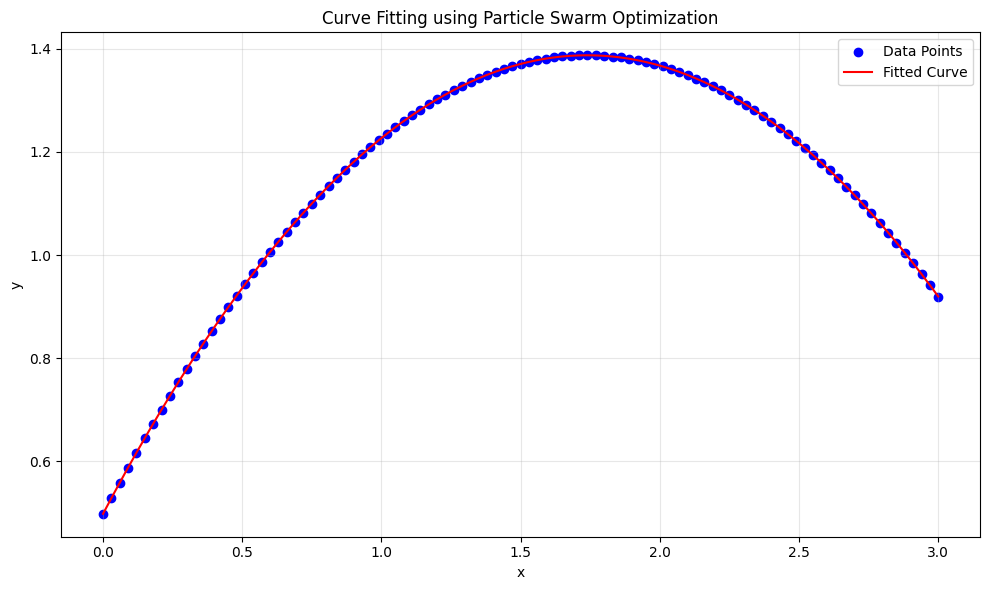

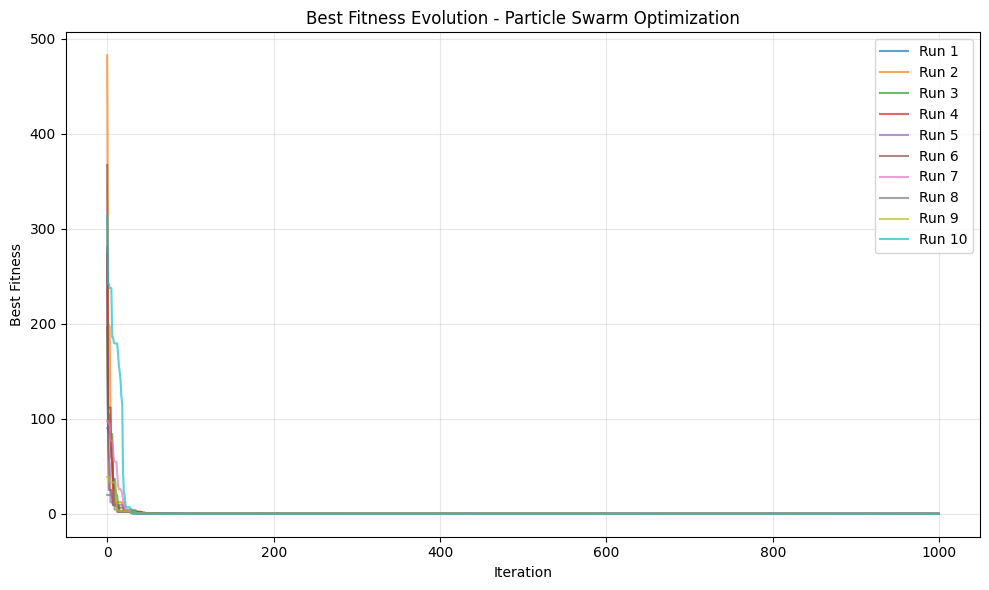

Running Genetic Algorithm 10 times...


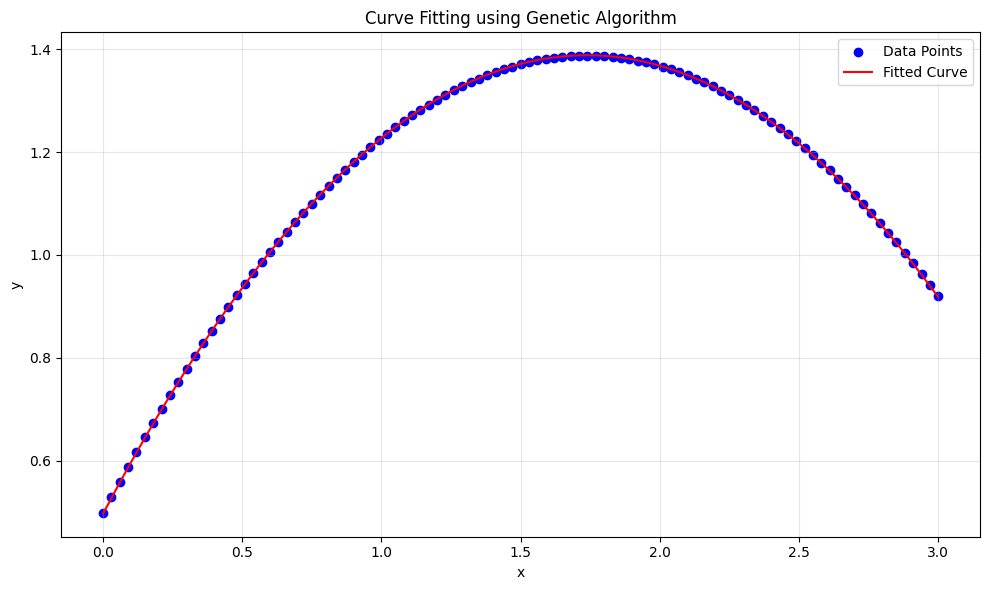

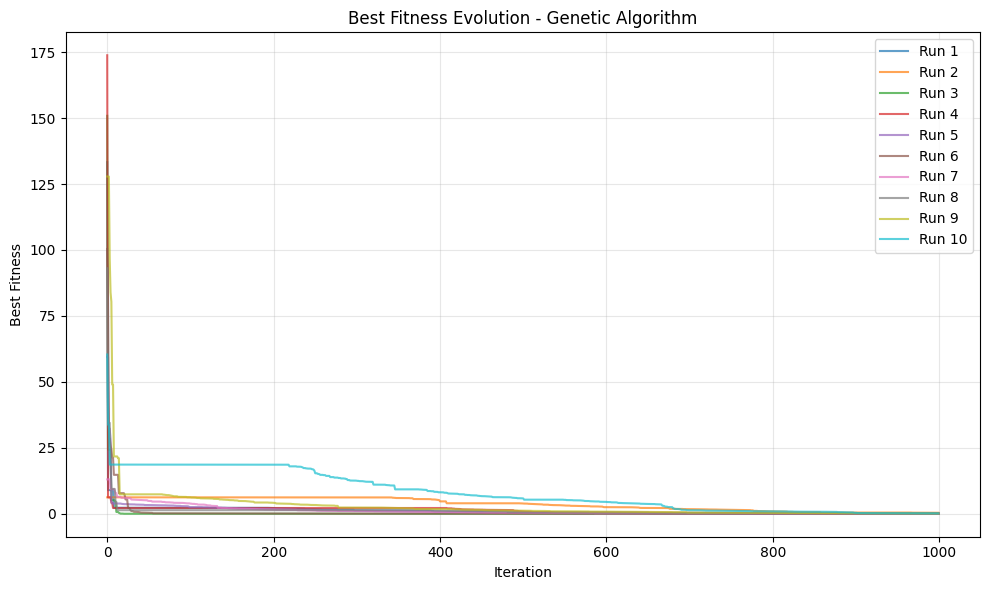

,Algorithm,Mean Fitness (10 exec.),Best Fitness
0,Particle Swarm Optimization,8.315238e-08,8.315238e-08
1,Genetic Algorithm,1.034339e-01,6.149086e-05


In [17]:
RUN_TIMES = 10

dataset = Dataset.from_txts('x_data.txt', 'y_data.txt')

algorithms: List[Algorithm] = [
    PsoAlgorithm(dataset),
    GaAlgorithm(dataset),
]

dataframe_rows = []

for algorithm in algorithms:
    print(f'Running {algorithm.name()} {RUN_TIMES} times...')
    algorithm.run_many_times(RUN_TIMES)

    algorithm.plot_curve_graphic()
    algorithm.plot_best_fitness_graphic()

    dataframe_rows.append(algorithm.get_dataframe_row())

dataframe = pd.DataFrame(dataframe_rows, columns=['algorithm', 'mean_fitness', 'min_fitness'])
dataframe.columns = ['Algorithm', 'Mean Fitness (10 exec.)', 'Best Fitness']
dataframe